Calculando 20000 dígitos de sqrt(2)...


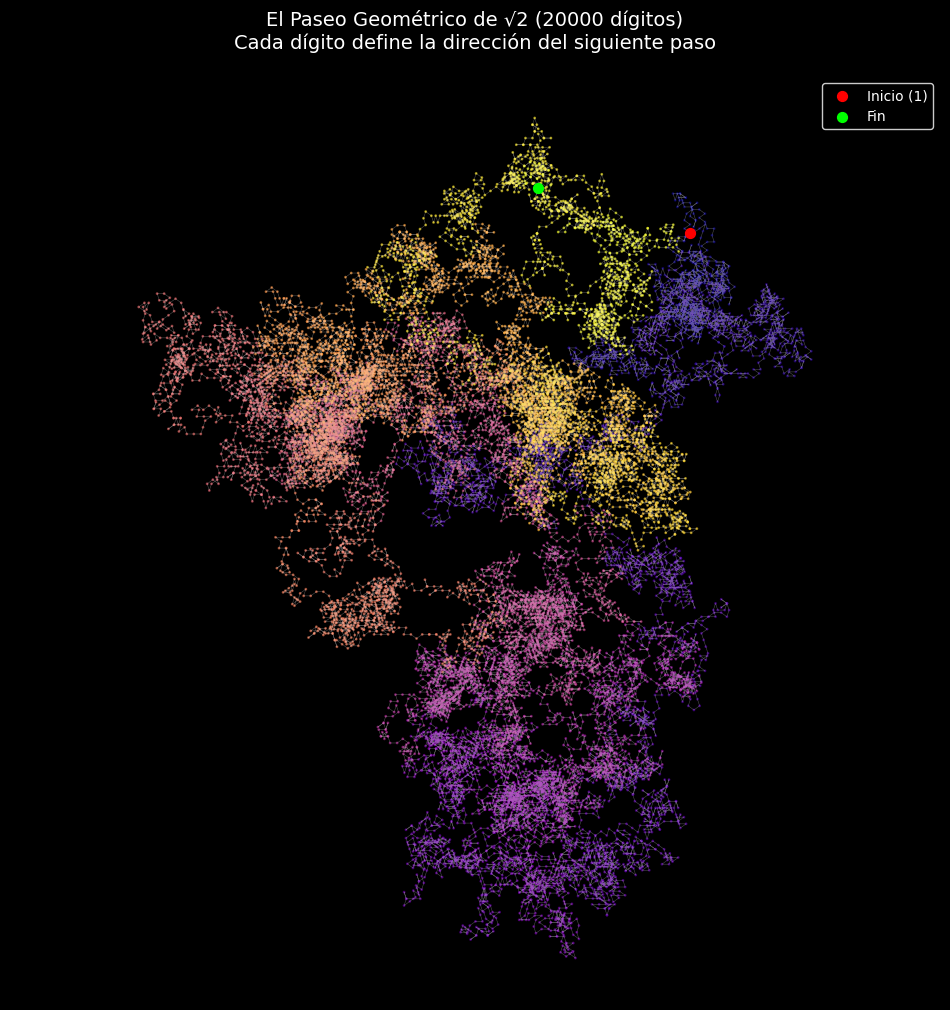

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpmath import mp

# --- CONFIGURACIÓN ---
# 20,000 dígitos crean un camino masivo y detallado
CANTIDAD_DIGITOS = 20000
mp.dps = CANTIDAD_DIGITOS + 5

print(f"Calculando {CANTIDAD_DIGITOS} dígitos de sqrt(2)...")
sqrt2_str = str(mp.sqrt(2)).replace('.', '')[:CANTIDAD_DIGITOS]
digitos = np.array([int(d) for d in sqrt2_str])

# --- LÓGICA DEL PASEO (DIGIT WALK) ---
# Cada dígito (0-9) se convierte en uno de los 10 ángulos posibles del círculo
angulos = digitos * (2 * np.pi / 10)

# Calculamos el desplazamiento individual de cada paso
dx = np.cos(angulos)
dy = np.sin(angulos)

# Sumamos acumulativamente para obtener las coordenadas (x, y) del camino
x = np.cumsum(dx)
y = np.cumsum(dy)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 12), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Dibujamos el sendero continuo
plt.plot(x, y, color='white', linewidth=0.4, alpha=0.3)

# Pintamos los puntos. El color cambia según el ORDEN (tiempo) para ver el recorrido
orden = np.arange(CANTIDAD_DIGITOS)
scatter = plt.scatter(x, y, c=orden, cmap='neon' if 'neon' in plt.colormaps() else 'plasma', s=1, alpha=0.6)

# Marcar el inicio y el final del camino
plt.scatter(x[0], y[0], color='red', s=50, label='Inicio (1)', zorder=5)
plt.scatter(x[-1], y[-1], color='lime', s=50, label='Fin', zorder=5)

# Estética
plt.title(f"El Paseo Geométrico de √2 ({CANTIDAD_DIGITOS} dígitos)\nCada dígito define la dirección del siguiente paso",
          color='white', fontsize=14, pad=20)
plt.axis('equal')
plt.axis('off')
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')

plt.show()
